## Problem Statements on Logistic Regression and Decision Tree

In [116]:
"""1. Download the seeds dataset from the below link and perform the following
operations.
https://archive.ics.uci.edu/ml/datasets/seeds
1. Read the dataset and seperate the input and output columns 
2. Plot the graph of class balancing
3. Perform train-test split with 80% and 20%
4. Create logistic regression model
5. Find accuracy, confusion matrix and classification report 6.
Perform the prediction of single value entry""";

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [118]:
df = pd.read_csv(
    "seeds_dataset.txt",
    sep=r"\s+",
    header=None,
)

df.columns = [
    "Area",
    "Perimeter",
    "Compactness",
    "Kernel_Length",
    "Kernel_Width",
    "Asymmetry_Coefficient",
    "Kernel_Groove_Length",
    "Class"
]

df.head()

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Kernel_Groove_Length,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area                   210 non-null    float64
 1   Perimeter              210 non-null    float64
 2   Compactness            210 non-null    float64
 3   Kernel_Length          210 non-null    float64
 4   Kernel_Width           210 non-null    float64
 5   Asymmetry_Coefficient  210 non-null    float64
 6   Kernel_Groove_Length   210 non-null    float64
 7   Class                  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [120]:
df.isnull().sum()

Area                     0
Perimeter                0
Compactness              0
Kernel_Length            0
Kernel_Width             0
Asymmetry_Coefficient    0
Kernel_Groove_Length     0
Class                    0
dtype: int64

In [121]:
x = df.drop("Class",axis=1)
y = df["Class"]

In [122]:
x

,Area,Perimeter,Compactness,Kernel_Length,Kernel_Width,Asymmetry_Coefficient,Kernel_Groove_Length
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175
...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044


In [123]:
y

0      1
1      1
2      1
3      1
4      1
      ..
205    3
206    3
207    3
208    3
209    3
Name: Class, Length: 210, dtype: int64

Text(0.5, 1.0, 'Class Balancing')

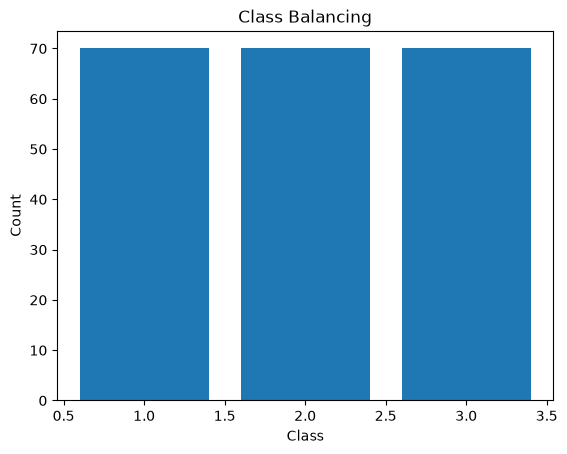

In [124]:
plt.bar(y.value_counts().index, y.value_counts().values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Balancing")

In [125]:
from sklearn.model_selection import train_test_split

In [126]:
x_train, x_test, y_train, y_test = train_test_split (x, y,test_size=0.2, random_state=42)

In [127]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [128]:
model.fit(x_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [129]:
y_pred = model.predict(x_test)


In [130]:
from sklearn.metrics import accuracy_score

In [131]:
print("Accuracy =", accuracy_score(y_test, y_pred))


Accuracy = 0.9047619047619048


In [132]:
sample = [[15.26, 14.84, 0.8710, 5.763, 3.312, 2.221, 5.220]]
result = model.predict(sample)

print("Predicted Class =", result[0])

Predicted Class = 1


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [133]:
"""2. Download the balance scale dataset from the below link and perform
following operations it.
https://archive.ics.uci.edu/ml/datasets/Balance+Scale
1. Read the dataset and seperate the input and output columns 2. Plot
the graph of class balancing
3. Perform train-test split with 75% and 25%
4. Create decision tree model
5. Find accuracy, confusion matrix and classification report 6.
Perform the prediction of single value entry.
7. Plot and save the tree""";

In [134]:
df = pd.read_csv("balance-scale.data", header=None)

In [135]:
df.columns = ["Class","Left_Weight","Left_Distance","Right_Weight","Right_Distance"]


In [136]:
df.head()

,Class,Left_Weight,Left_Distance,Right_Weight,Right_Distance
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Class           625 non-null    str  
 1   Left_Weight     625 non-null    int64
 2   Left_Distance   625 non-null    int64
 3   Right_Weight    625 non-null    int64
 4   Right_Distance  625 non-null    int64
dtypes: int64(4), str(1)
memory usage: 24.5 KB


In [138]:
df.isnull().sum()

Class             0
Left_Weight       0
Left_Distance     0
Right_Weight      0
Right_Distance    0
dtype: int64

In [139]:
x = df.drop("Class", axis=1)
y = df["Class"]


Text(0.5, 1.0, 'Class Balancing')

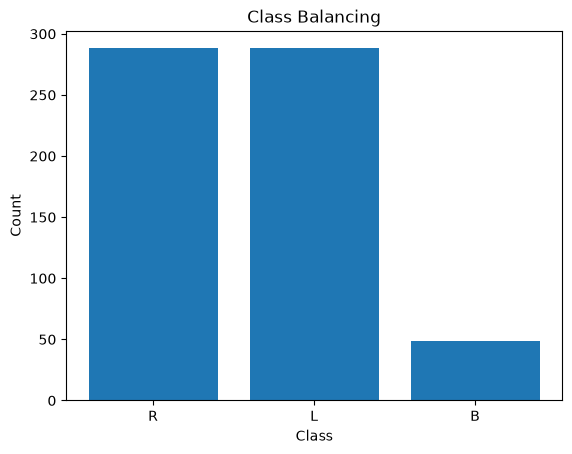

In [140]:
plt.bar(y.value_counts().index, y.value_counts().values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Balancing")

In [141]:
x_train, x_test, y_train, y_test = train_test_split( x,y,test_size=0.25, random_state=42)

In [142]:
from sklearn.tree import DecisionTreeClassifier

In [143]:
model = DecisionTreeClassifier(random_state=42)

In [144]:
model.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [145]:
y_pred = model.predict(x_test)


In [146]:
print("Accuracy =", accuracy_score(y_test, y_pred))


Accuracy = 0.7579617834394905


In [147]:
sample = [[1,1,1,1]]
result = model.predict(sample)

print("Predicted Class =", result)


Predicted Class = ['B']


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [148]:
from sklearn.tree import plot_tree

Text(0.5, 1.0, 'Decision Tree')

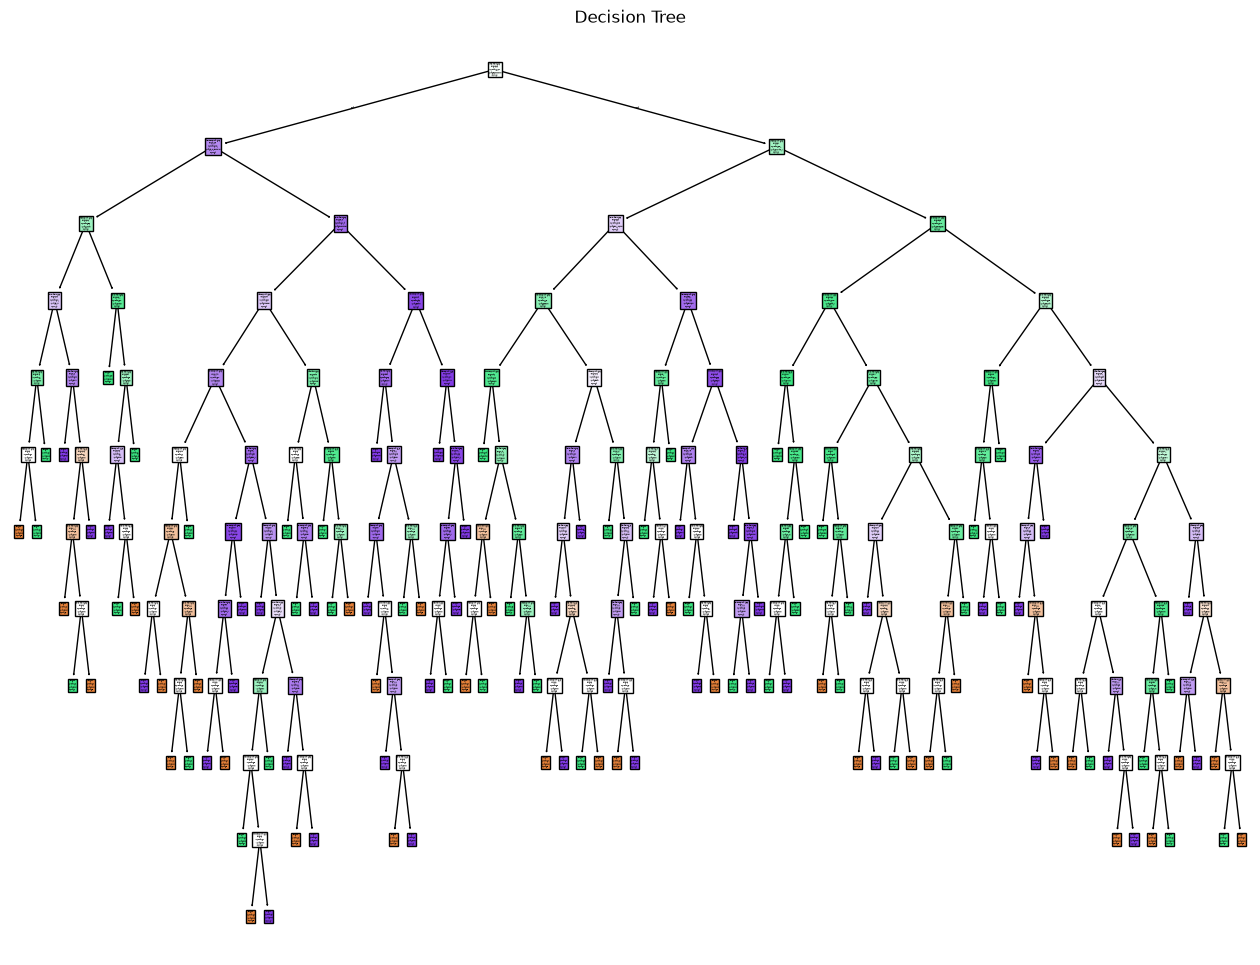

In [149]:
plt.figure(figsize=(16,12))
plot_tree(
    model,
    feature_names=x.columns,
    class_names=model.classes_,
    filled=True
)
plt.title("Decision Tree")


In [150]:
"""3. Download the balance scale dataset from the below link and perform
following operations it.
https://archive.ics.uci.edu/ml/datasets/Computer+Hardware 1. Read
the dataset and seperate the input and output columns 2. Perform
train-test split with 75% and 25%
3. Create decision tree model
4. Find Mean absolute error and accuracy
5. Perform the prediction of single value entry.
6. Plot and save the tree""";

In [151]:
df = pd.read_csv("machine.data", header=None)

In [152]:
df.columns = ["Vendor","Model","MYCT","MMIN","MMAX","CACH","CHMIN","CHMAX","PRP","ERP"]

In [153]:
df.head()

,Vendor,Model,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX,PRP,ERP
0,adviser,32/60,125,256,6000,256,16,128,198,199
1,amdahl,470v/7,29,8000,32000,32,8,32,269,253
2,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
3,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
4,amdahl,470v/7c,29,8000,16000,32,8,16,132,132


In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Vendor  209 non-null    str  
 1   Model   209 non-null    str  
 2   MYCT    209 non-null    int64
 3   MMIN    209 non-null    int64
 4   MMAX    209 non-null    int64
 5   CACH    209 non-null    int64
 6   CHMIN   209 non-null    int64
 7   CHMAX   209 non-null    int64
 8   PRP     209 non-null    int64
 9   ERP     209 non-null    int64
dtypes: int64(8), str(2)
memory usage: 16.5 KB


In [155]:
x = df[["MYCT","MMIN","MMAX","CACH","CHMIN","CHMAX"]]
y = df["PRP"]


In [156]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.25,random_state=42)

In [157]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()


In [158]:
model.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [159]:
y_pred = model.predict(x_test)


In [160]:
from sklearn.metrics import mean_absolute_error


In [161]:
 mean_absolute_error(y_test, y_pred)

69.71698113207547

In [162]:
from sklearn.metrics import r2_score


In [163]:
print("Accuracy =", r2_score(y_test, y_pred))


Accuracy = 0.5840333405698181


In [164]:
sample = [[125,256,6000,64,16,128]]

result = model.predict(sample)

print("Predicted PRP =", result)


Predicted PRP = [144.]


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Decision Tree')

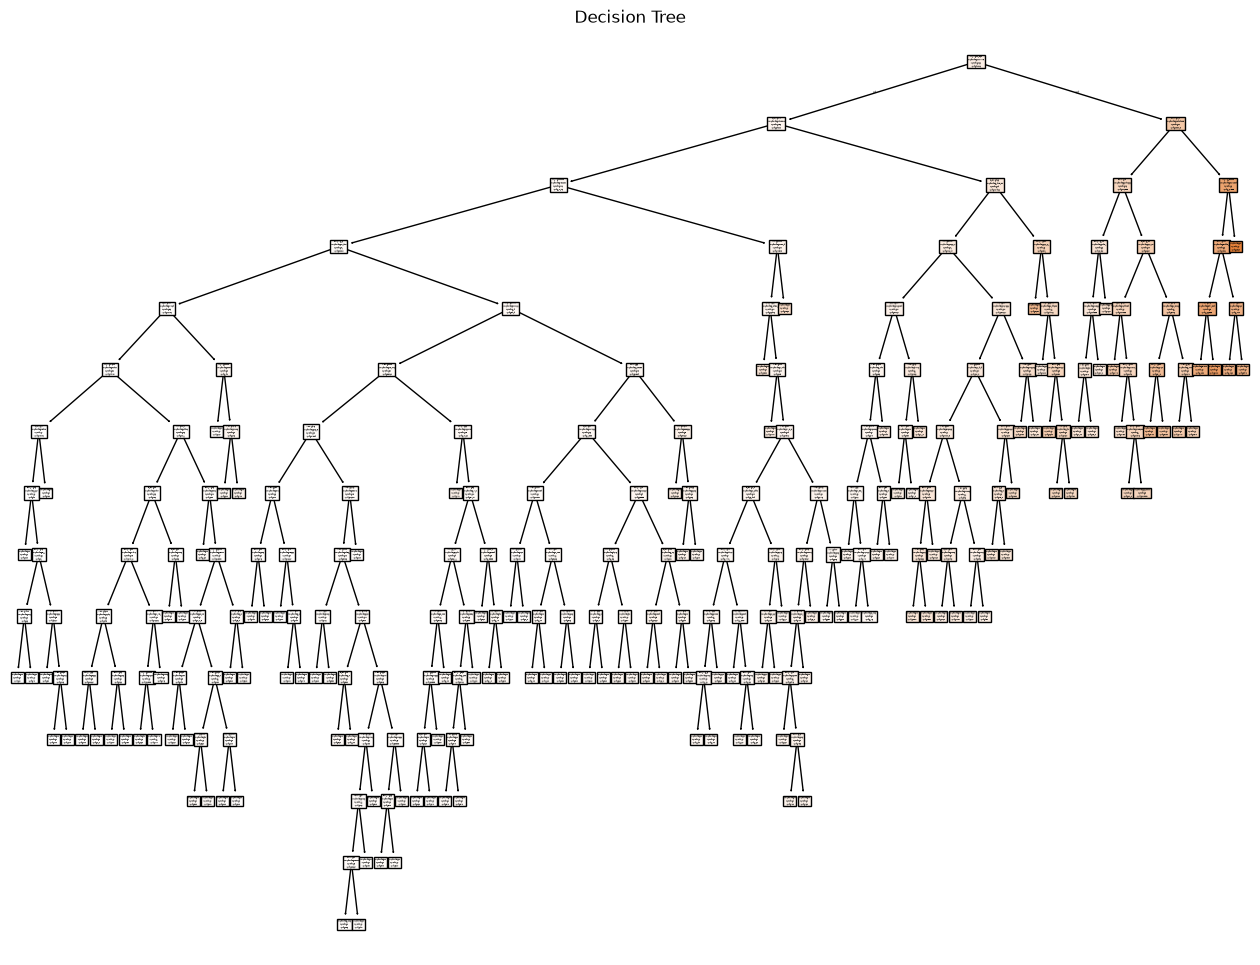

In [165]:
plt.figure(figsize=(16,12))
plot_tree(
    model,
    feature_names=x.columns,
    filled=True
)

plt.title("Decision Tree")
